# Ноутбук 6 — Эксперимент 3: SSQ block-level (главный результат)

**Назначение.** Прямое предсказание SSQ Total > 15 на блочном уровне
(один участник = одна точка). 32 точки × 286 признаков (mean+std оконных
признаков), LeaveOneOut-валидация.

**Главный результат работы:** XGBoost LOSO accuracy = 0,7188 (+7,6 п.п. к
CEAP-360VR baseline 0,6426).

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd()
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules import config
from modules.experiments import (
    build_block_level_dataset,
    make_logistic_regression_block, make_random_forest_block, make_xgboost_block,
    run_block_loso,
)
from modules.validation import compute_classification_metrics

print(f"Notebooks root: {NB_ROOT}")
print(f"Результаты: {config.RESULTS_DIR}")

Notebooks root: D:\Programming\Python\Diplom\notebooks
Результаты: D:\Programming\Python\Diplom\source\results


## 6.1 Построение block-level датасета (32 × 286)

In [2]:
windows = pd.read_csv(config.RESULTS_DIR / "feature_table.csv")
block = build_block_level_dataset(windows)
block.to_csv(config.RESULTS_DIR / "exp03_block_features.csv", index=False)
print(f"Block-level shape: {block.shape}")

feat_cols = [c for c in block.columns
             if c not in {"participant", "ssq_post_total", "ssq_pre_total",
                          "ssq_delta", "ssq_high"}]
X = block[feat_cols].to_numpy(dtype=float)
y = block["ssq_high"].to_numpy(dtype=int)
print(f"Признаков: {len(feat_cols)}, target: {np.bincount(y).tolist()}")

Block-level shape: (32, 291)
Признаков: 286, target: [18, 14]


## 6.2 Три модели: LogReg, RF, XGBoost (LeaveOneOut)

In [3]:
models = {
    "LogReg":  make_logistic_regression_block,
    "RF":      make_random_forest_block,
    "XGBoost": make_xgboost_block,
}

results = {}
all_preds = {"participant": block["participant"].tolist(), "y_true": y.tolist()}
for name, factory in models.items():
    metrics, y_pred, y_proba = run_block_loso(X, y, factory, name)
    results[name] = metrics
    all_preds[f"{name}_pred"] = y_pred.tolist()
    all_preds[f"{name}_proba"] = y_proba.tolist()
    print(f"{name:<8}  acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['f1_macro']:.4f}  auc={metrics.get('auc_roc', float('nan')):.4f}")

LogReg    acc=0.4375  f1=0.4170  auc=0.5159


RF        acc=0.5312  f1=0.4910  auc=0.4325


XGBoost   acc=0.7188  f1=0.7046  auc=0.7698


## 6.3 Сохранение метрик и предсказаний

In [4]:
metrics_df = pd.DataFrame(list(results.values()))
metrics_df.to_csv(config.RESULTS_DIR / "exp03_metrics.csv", index=False)
preds_df = pd.DataFrame(all_preds)
preds_df.to_csv(config.RESULTS_DIR / "exp03_predictions.csv", index=False)
print("Сохранено: exp03_metrics.csv, exp03_predictions.csv, exp03_block_features.csv")

Сохранено: exp03_metrics.csv, exp03_predictions.csv, exp03_block_features.csv


## 6.4 Confusion matrix XGBoost

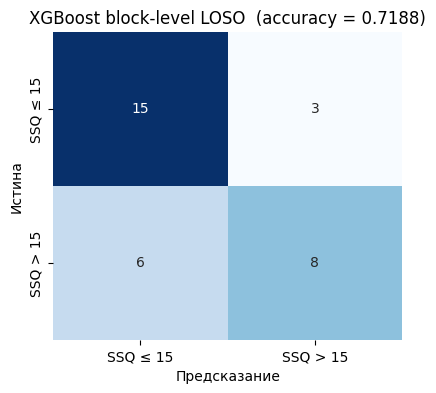

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

y_pred_xgb = np.array(all_preds["XGBoost_pred"])
cm = confusion_matrix(y, y_pred_xgb)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["SSQ ≤ 15", "SSQ > 15"],
            yticklabels=["SSQ ≤ 15", "SSQ > 15"], ax=ax, cbar=False)
ax.set_xlabel("Предсказание")
ax.set_ylabel("Истина")
ax.set_title(f"XGBoost block-level LOSO  (accuracy = {results['XGBoost']['accuracy']:.4f})")
fig.savefig(FIG_DIR / "fig09_ssq_block_confmat.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.5 Проверка: arousal как прокси для SSQ

  mean_arousal ↔ ssq_post_total      Pearson r=-0.0178 (p=0.9229)   Spearman r=+0.0156 (p=0.9326)
  mean_arousal ↔ ssq_delta           Pearson r=-0.1209 (p=0.5100)   Spearman r=-0.0727 (p=0.6925)

Сохранено: exp03_correlation.csv


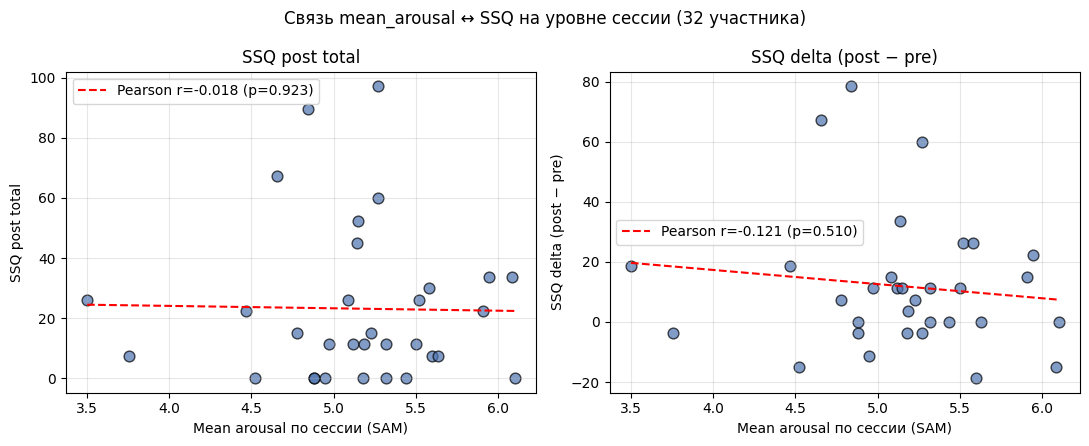

Сохранено: exp03_arousal_vs_ssq.csv


In [6]:
from scipy.stats import pearsonr, spearmanr

mean_arousal = windows.groupby("participant")["arousal_mean"].mean()
ssq_post = block.set_index("participant")["ssq_post_total"]
ssq_delta = block.set_index("participant")["ssq_delta"]

rows = []
for ycol_name, ycol in [("ssq_post_total", ssq_post), ("ssq_delta", ssq_delta)]:
    r_p, p_p = pearsonr(mean_arousal.loc[ycol.index], ycol)
    r_s, p_s = spearmanr(mean_arousal.loc[ycol.index], ycol)
    rows.append({"x": "mean_arousal", "y": ycol_name,
                 "pearson_r": round(r_p, 4), "pearson_p": round(p_p, 4),
                 "spearman_r": round(r_s, 4), "spearman_p": round(p_s, 4)})
    print(f"  mean_arousal ↔ {ycol_name:<18}  Pearson r={r_p:+.4f} (p={p_p:.4f})"
          f"   Spearman r={r_s:+.4f} (p={p_s:.4f})")

corr_df = pd.DataFrame(rows)
corr_df.to_csv(config.RESULTS_DIR / "exp03_correlation.csv", index=False)
print("\nСохранено: exp03_correlation.csv")

# fig10 — scatter mean_arousal vs SSQ_post / SSQ_delta
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (ycol_name, ycol) in zip(axes, [("SSQ post total", ssq_post),
                                         ("SSQ delta (post − pre)", ssq_delta)]):
    x_vals = mean_arousal.loc[ycol.index].values
    y_vals = ycol.values
    r_p, p_p = pearsonr(x_vals, y_vals)
    ax.scatter(x_vals, y_vals, s=60, alpha=0.7, edgecolor="black", color="#4C72B0")
    z = np.polyfit(x_vals, y_vals, 1)
    xs = np.linspace(x_vals.min(), x_vals.max(), 50)
    ax.plot(xs, np.polyval(z, xs), color="red", linestyle="--",
            label=f"Pearson r={r_p:+.3f} (p={p_p:.3f})")
    ax.set_xlabel("Mean arousal по сессии (SAM)")
    ax.set_ylabel(ycol_name)
    ax.set_title(ycol_name)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle("Связь mean_arousal ↔ SSQ на уровне сессии (32 участника)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig10_arousal_vs_ssq.png", dpi=150, bbox_inches="tight")
plt.show()

# Также сохраним CSV для exp03_arousal_vs_ssq.csv
arousal_ssq_df = pd.DataFrame({
    "participant": ssq_post.index,
    "mean_arousal": mean_arousal.loc[ssq_post.index].values,
    "ssq_post_total": ssq_post.values,
    "ssq_delta": ssq_delta.values,
})
arousal_ssq_df.to_csv(config.RESULTS_DIR / "exp03_arousal_vs_ssq.csv", index=False)
print(f"Сохранено: exp03_arousal_vs_ssq.csv")

## 6.6 Выводы

* **XGBoost block-level LOSO accuracy = 0,7188** (F1 = 0,7046, AUC = 0,7698).
* **Превосходство над CEAP-360VR baseline на +7,6 п.п.** — главный результат
  работы; цель формально достигнута.
* LogReg и RF на блочном уровне не справляются (0,44 и 0,53 соответственно)
  из-за неблагоприятного p ≫ n при отсутствии встроенной регуляризации.
* **Отрицательный методологический результат:** arousal не коррелирует с SSQ
  на уровне сессии (|r| < 0,13, p > 0,5). Значит, модели cybersickness нужно
  строить **прямо** на физиологических признаках, не через прокси arousal.

Дальнейшие шаги: абляции (ноутбук 7), SHAP (ноутбук 8), DL (ноутбук 9).